Assignment 3 Python Code for visualization

In [1]:
# import the necessary pacagkes
import pandas as pd
import matplotlib.pyplot as plt

# load the data
URL = "https://files.ontario.ca/moe_mapping/downloads/2Water/GLIP/All_Lakes_GLIP_1976_2024.xlsx"
water_quality = pd.read_excel(URL)


In [9]:
# Filter the data to select chlorphyLL
chl = water_quality[water_quality['PARAMETER'].str.contains('chlorophyll', case = False, na = False)]
chl = chl.dropna(subset = ['RESULT_VALUE', 'YEAR'])


In [12]:
# Compute the Annual Mean Values
Year_mean = (chl.groupby('YEAR')['RESULT_VALUE']
             .mean()
             .reset_index()
             )

# Compute the Annual Median Values
Year_median = (chl.groupby('YEAR')['RESULT_VALUE']
               .median()
               .reset_index())

# Compute the station-based balancing mean values
Station_year = (chl.groupby(['STATION','YEAR'])['RESULT_VALUE']
             .mean()
             .reset_index()
             )

Balanced_mean = (Station_year.groupby('YEAR')['RESULT_VALUE']
             .mean()
             .reset_index()
             )



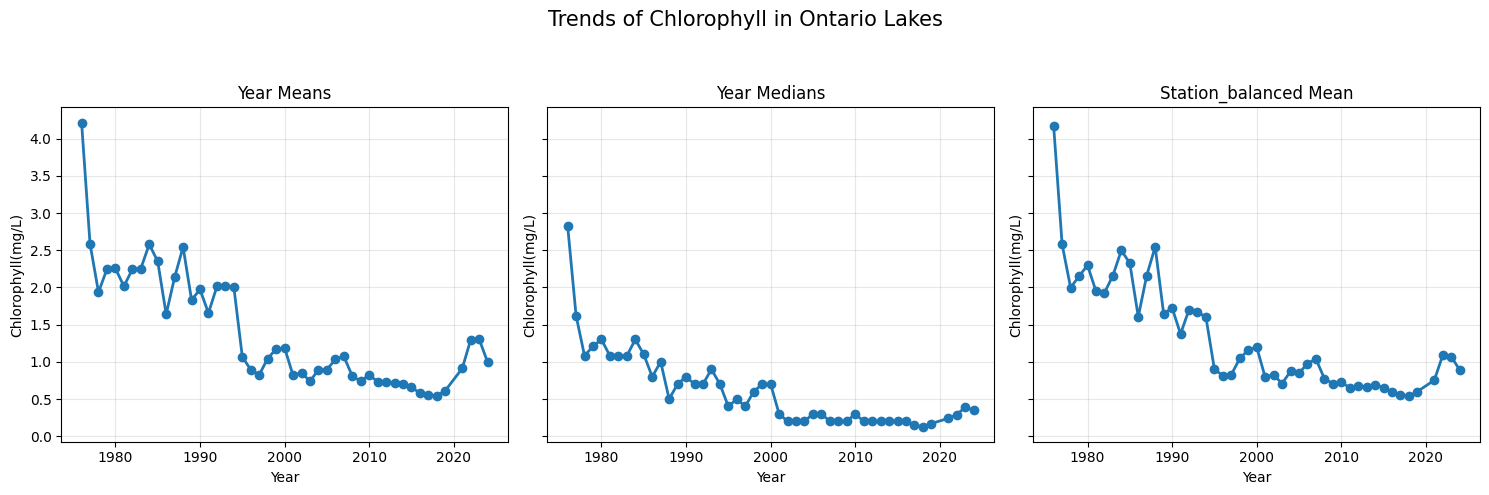

In [25]:
# Create the subplots of the mean, median, and balanced mean values
fig, ax = plt.subplots(1, 3, figsize = (15,5), sharey = True)

# plot for mean
ax[0].plot(
    Year_mean['YEAR'],
    Year_mean['RESULT_VALUE'],
    marker = 'o',
    linewidth = 2
)
ax[0].set_title('Year Means')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Chlorophyll(mg/L)')
#ax[0].set_yscale('log')
ax[0].grid(alpha = 0.3)

# plot for median
ax[1].plot(
    Year_median['YEAR'],
    Year_median['RESULT_VALUE'],
    marker = 'o',
    linewidth = 2
)
ax[1].set_title('Year Medians')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Chlorophyll(mg/L)')
#ax[1].set_yscale('log')
ax[1].grid(alpha = 0.3)

# plot the balanced values
ax[2].plot(
    Balanced_mean['YEAR'],
    Balanced_mean['RESULT_VALUE'],
    marker = 'o',
    linewidth = 2
)
ax[2].set_title('Station_balanced Mean')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Chlorophyll(mg/L)')
#ax[2].set_yscale('log')
ax[2].grid(alpha = 0.3)

fig.suptitle(
    'Trends of Chlorophyll in Ontario Lakes',
    fontsize = 15
)

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

